# Consumer Complaint Classification

## Setup

In [1]:
!pip install -q "transformers==4.46.0" datasets nltk tf-keras

import re
import time
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.6 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 73.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 96.2 MB/s eta 0:00:00


## Stage 1 — Data Exploration

In [2]:
DATA_PATH = "/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv"

df = pd.read_csv(DATA_PATH)
if df.columns[0].startswith("Unnamed"):
    df = df.drop(columns=[df.columns[0]])

df.head()


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [3]:
print(df.shape)
print(df.isna().sum())
print(df.duplicated().sum())


(162421, 2)
product       0
narrative    10
dtype: int64
37742


In [4]:
df = df.dropna(subset=['narrative'])
df = df.drop_duplicates(subset=['narrative'])
df = df.reset_index(drop=True)
print(df.shape)


(124472, 2)


In [5]:
print(df['product'].value_counts())


product
credit_reporting       56240
debt_collection        21057
mortgages_and_loans    18723
credit_card            14983
retail_banking         13469
Name: count, dtype: int64


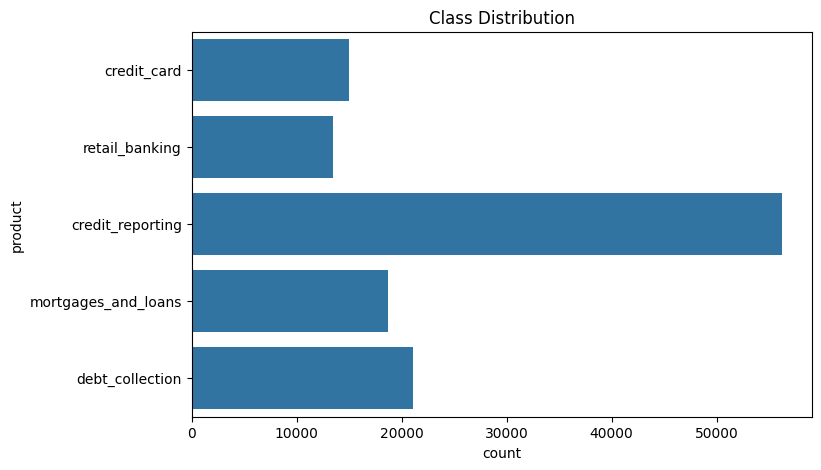

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='product')
plt.title('Class Distribution')
plt.show()


## Stage 2 — Text Preprocessing

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)


In [8]:
df['clean_narrative'] = df['narrative'].apply(clean_text)
df = df[df['clean_narrative'].str.len() > 0]
df = df.reset_index(drop=True)
df[['narrative', 'clean_narrative']].head()


,narrative,clean_narrative
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


## Sample the Data and Split into Train / Validation / Test

In [9]:
SAMPLE_SIZE = 70000

df_sample, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df['product'], random_state=42)
print(df_sample.shape)


(70000, 3)


In [10]:
le = LabelEncoder()
df_sample['label'] = le.fit_transform(df_sample['product'])
NUM_CLASSES = len(le.classes_)
print(list(le.classes_))


['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']


In [11]:
X = df_sample['clean_narrative'].values
y = df_sample['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)


(49000,) (10500,) (10500,)


In [12]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(class_weights)


{0: np.float64(1.6615801966768395), 1: np.float64(0.44263775971093045), 2: np.float64(1.1822897816383158), 3: np.float64(1.3297150610583446), 4: np.float64(1.8480105600603431)}


## Stage 3 — Text Tokenization

In [13]:
VOCAB_SIZE = 20000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(X_train_pad.shape)


(49000, 150)


## Stage 4 — Word Embedding

In [14]:
EMBEDDING_DIM = 128


## Evaluation Function
(used after training every model)

In [15]:
results = {}

def evaluate_model(model, X_test_input, y_test_input, name, train_time, y_pred=None):
    if y_pred is None:
        probs = model.predict(X_test_input, verbose=0)
        y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test_input, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_input, y_pred, average='weighted')

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 score:", f1)
    print("Training time (seconds):", train_time)
    print(classification_report(y_test_input, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test_input, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.show()

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'train_time_sec': train_time}


## Stage 5 — Model 1: SimpleRNN

In [16]:
model_rnn = Sequential()
model_rnn.add(Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dropout(0.4))
model_rnn.add(Dense(64, activation='relu'))
model_rnn.add(Dropout(0.3))
model_rnn.add(Dense(NUM_CLASSES, activation='softmax'))

model_rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_rnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784487267.030992      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784487267.033755      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

start = time.time()
model_rnn.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
              epochs=10, batch_size=128, class_weight=class_weights, callbacks=[early_stop])
train_time_rnn = time.time() - start


Epoch 1/10
  7/383 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.1789 - loss: 1.6081

I0000 00:00:1784487272.105335     149 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.2632 - loss: 1.6064 - val_accuracy: 0.4610 - val_loss: 1.5559
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2907 - loss: 1.5724 - val_accuracy: 0.2022 - val_loss: 1.5828
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3631 - loss: 1.5307 - val_accuracy: 0.4574 - val_loss: 1.6303


SimpleRNN
Accuracy: 0.4621904761904762
Precision: 0.3601773863162645
Recall: 0.4621904761904762
F1 score: 0.33666208587348706
Training time (seconds): 25.330164670944214
                     precision    recall  f1-score   support

        credit_card       0.19      0.01      0.02      1264
   credit_reporting       0.48      0.94      0.64      4744
    debt_collection       0.33      0.02      0.03      1777
mortgages_and_loans       0.31      0.22      0.26      1579
     retail_banking       0.13      0.01      0.01      1136

           accuracy                           0.46     10500
          macro avg       0.29      0.24      0.19     10500
       weighted avg       0.36      0.46      0.34     10500



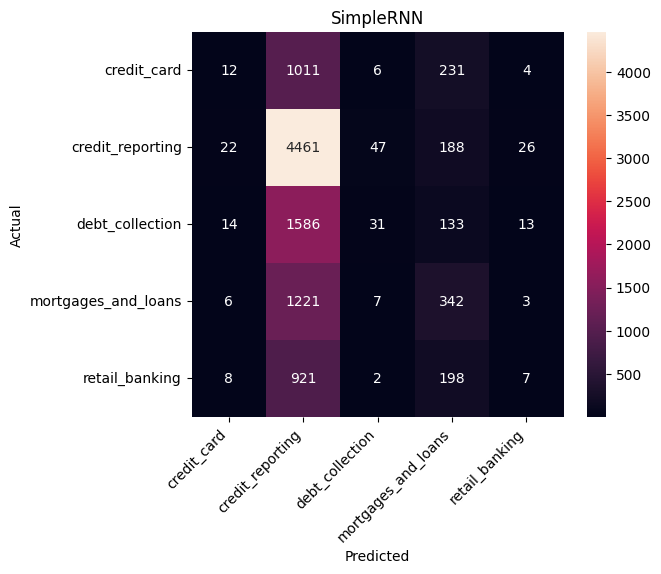

In [18]:
evaluate_model(model_rnn, X_test_pad, y_test, 'SimpleRNN', train_time_rnn)


## Model 2: LSTM

In [19]:
model_lstm = Sequential()
model_lstm.add(Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN))
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.4))
model_lstm.add(Dense(64, activation='relu'))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(NUM_CLASSES, activation='softmax'))

model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [20]:
start = time.time()
model_lstm.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
               epochs=10, batch_size=128, class_weight=class_weights, callbacks=[early_stop])
train_time_lstm = time.time() - start


Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2898 - loss: 1.5746 - val_accuracy: 0.2034 - val_loss: 1.5517
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3716 - loss: 1.4184 - val_accuracy: 0.3687 - val_loss: 1.0518
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5231 - loss: 0.9538 - val_accuracy: 0.5562 - val_loss: 0.9247
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7218 - loss: 0.7870 - val_accuracy: 0.7819 - val_loss: 0.6602
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8143 - loss: 0.5891 - val_accuracy: 0.8122 - val_loss: 0.5891
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7882 - loss: 0.6563 - val_accuracy: 0.7805 - val_loss: 0.6339
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8207 - loss: 0.5381 - val_accuracy: 0.8081 - val_loss: 0.6004


LSTM
Accuracy: 0.8151428571428572
Precision: 0.8203386852341682
Recall: 0.8151428571428572
F1 score: 0.8159673290292735
Training time (seconds): 37.99036478996277
                     precision    recall  f1-score   support

        credit_card       0.78      0.69      0.73      1264
   credit_reporting       0.90      0.83      0.86      4744
    debt_collection       0.71      0.79      0.75      1777
mortgages_and_loans       0.78      0.85      0.81      1579
     retail_banking       0.79      0.88      0.83      1136

           accuracy                           0.82     10500
          macro avg       0.79      0.81      0.80     10500
       weighted avg       0.82      0.82      0.82     10500



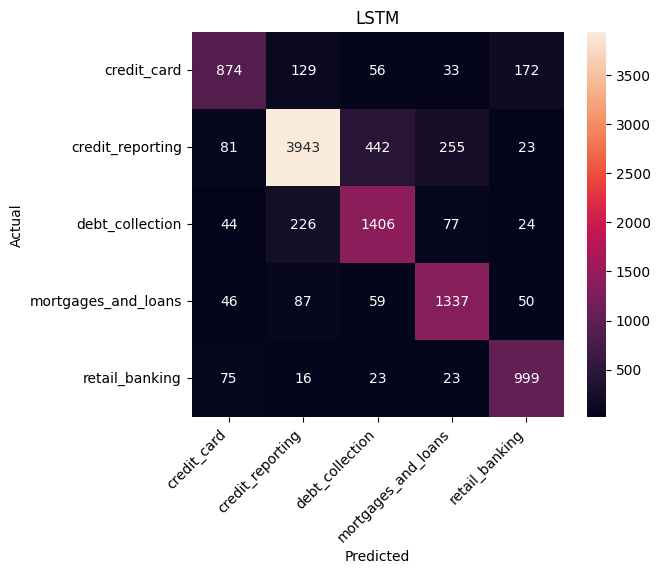

In [21]:
evaluate_model(model_lstm, X_test_pad, y_test, 'LSTM', train_time_lstm)


## Model 3: GRU

In [22]:
model_gru = Sequential()
model_gru.add(Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN))
model_gru.add(GRU(64))
model_gru.add(Dropout(0.4))
model_gru.add(Dense(64, activation='relu'))
model_gru.add(Dropout(0.3))
model_gru.add(Dense(NUM_CLASSES, activation='softmax'))

model_gru.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
start = time.time()
model_gru.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
              epochs=10, batch_size=128, class_weight=class_weights, callbacks=[early_stop])
train_time_gru = time.time() - start


Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2789 - loss: 1.5655 - val_accuracy: 0.2410 - val_loss: 1.4349
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4650 - loss: 1.0948 - val_accuracy: 0.6287 - val_loss: 0.8807


GRU
Accuracy: 0.23895238095238094
Precision: 0.45202888745743125
Recall: 0.23895238095238094
F1 score: 0.18042216831932795
Training time (seconds): 10.95747995376587
                     precision    recall  f1-score   support

        credit_card       0.25      0.04      0.08      1264
   credit_reporting       0.58      0.02      0.04      4744
    debt_collection       0.24      0.07      0.11      1777
mortgages_and_loans       0.69      0.78      0.73      1579
     retail_banking       0.13      0.87      0.22      1136

           accuracy                           0.24     10500
          macro avg       0.38      0.36      0.24     10500
       weighted avg       0.45      0.24      0.18     10500



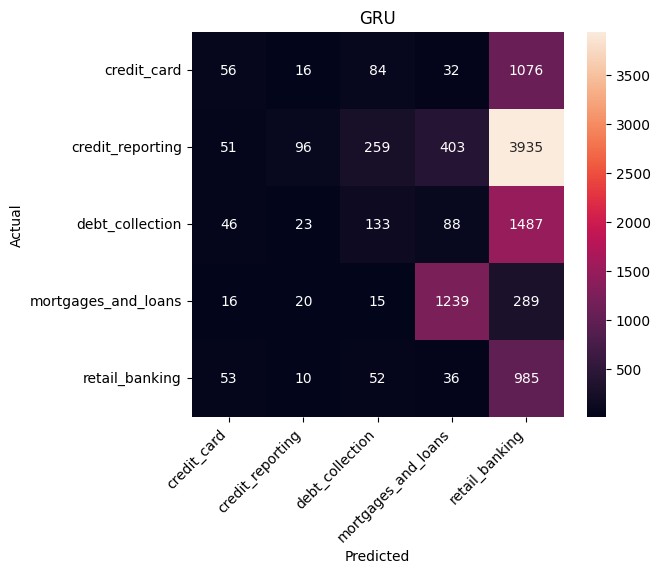

In [24]:
evaluate_model(model_gru, X_test_pad, y_test, 'GRU', train_time_gru)


## Model 4: Fine-Tuned Transformer (DistilBERT)

In [25]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import Dataset

MODEL_NAME = 'distilbert-base-uncased'
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_dict({'text': list(X_train), 'label': list(y_train)})
val_ds = Dataset.from_dict({'text': list(X_val), 'label': list(y_val)})
test_ds = Dataset.from_dict({'text': list(X_test), 'label': list(y_test)})

def tokenize_batch(batch):
    return hf_tokenizer(batch['text'], truncation=True, max_length=150)

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds = val_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

collator = DataCollatorWithPadding(tokenizer=hf_tokenizer, return_tensors='tf')

tf_train = train_ds.to_tf_dataset(columns=['input_ids','attention_mask'], label_cols='label', shuffle=True, batch_size=32, collate_fn=collator)
tf_val = val_ds.to_tf_dataset(columns=['input_ids','attention_mask'], label_cols='label', shuffle=False, batch_size=32, collate_fn=collator)
tf_test = test_ds.to_tf_dataset(columns=['input_ids','attention_mask'], label_cols='label', shuffle=False, batch_size=32, collate_fn=collator)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/49000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

In [26]:
transformer_model = TFAutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES)

import tf_keras

transformer_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

start = time.time()
transformer_model.fit(tf_train, validation_data=tf_val, epochs=2)
train_time_transformer = time.time() - start


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/2
1532/1532 [==============================] - 857s 545ms/step - loss: 0.5485 - accuracy: 0.8053 - val_loss: 0.4581 - val_accuracy: 0.8333
Epoch 2/2
1532/1532 [==============================] - 836s 546ms/step - loss: 0.3878 - accuracy: 0.8624 - val_loss: 0.4219 - val_accuracy: 0.8528


329/329 [==============================] - 61s 181ms/step
Transformer (DistilBERT)
Accuracy: 0.8563809523809524
Precision: 0.8561861111838506
Recall: 0.8563809523809524
F1 score: 0.8550561927197526
Training time (seconds): 1693.60489320755
                     precision    recall  f1-score   support

        credit_card       0.80      0.83      0.81      1264
   credit_reporting       0.87      0.91      0.89      4744
    debt_collection       0.85      0.71      0.78      1777
mortgages_and_loans       0.85      0.86      0.85      1579
     retail_banking       0.86      0.90      0.88      1136

           accuracy                           0.86     10500
          macro avg       0.85      0.84      0.84     10500
       weighted avg       0.86      0.86      0.86     10500



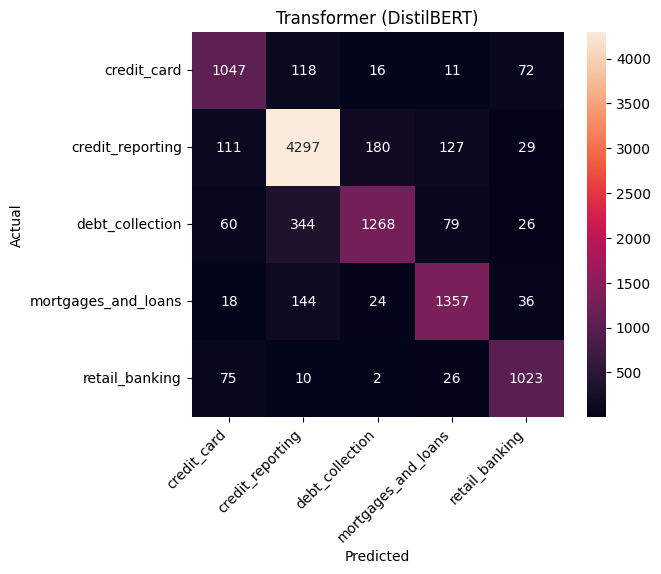

In [27]:
logits = transformer_model.predict(tf_test).logits
y_pred_transformer = np.argmax(logits, axis=1)

evaluate_model(None, None, y_test, 'Transformer (DistilBERT)', train_time_transformer, y_pred=y_pred_transformer)


## Stage 6 & 7 — Performance Comparison

In [28]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1', 'train_time_sec']]
comparison_df = comparison_df.sort_values('f1', ascending=False)
comparison_df


,accuracy,precision,recall,f1,train_time_sec
Transformer (DistilBERT),0.856381,0.856186,0.856381,0.855056,1693.604893
LSTM,0.815143,0.820339,0.815143,0.815967,37.990365
SimpleRNN,0.462190,0.360177,0.462190,0.336662,25.330165
GRU,0.238952,0.452029,0.238952,0.180422,10.957480


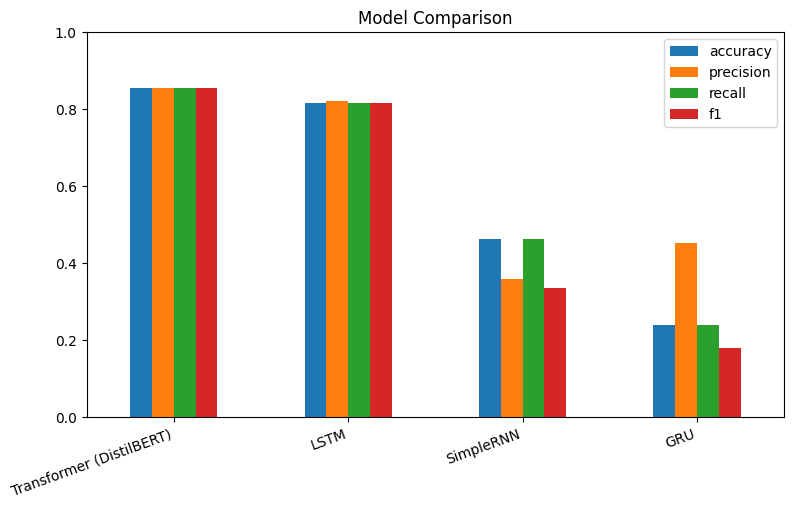

Transformer (DistilBERT)


In [29]:
comparison_df[['accuracy','precision','recall','f1']].plot(kind='bar', figsize=(9,5))
plt.title('Model Comparison')
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
plt.show()

best_model_name = comparison_df.index[0]
print(best_model_name)


## Stage 8 — Save Best Model

In [30]:
SAVE_DIR = '/kaggle/working/best_model'
os.makedirs(SAVE_DIR, exist_ok=True)

if best_model_name == 'Transformer (DistilBERT)':
    transformer_model.save_pretrained(SAVE_DIR)
    hf_tokenizer.save_pretrained(SAVE_DIR)
    with open(os.path.join(SAVE_DIR, 'label_encoder.pkl'), 'wb') as f:
        pickle.dump(le, f)
    with open(os.path.join(SAVE_DIR, 'model_type.txt'), 'w') as f:
        f.write('transformer')
else:
    model_map = {'SimpleRNN': model_rnn, 'LSTM': model_lstm, 'GRU': model_gru}
    best_keras_model = model_map[best_model_name]
    best_keras_model.save(os.path.join(SAVE_DIR, 'model.keras'))
    with open(os.path.join(SAVE_DIR, 'tokenizer.pkl'), 'wb') as f:
        pickle.dump(tokenizer, f)
    with open(os.path.join(SAVE_DIR, 'label_encoder.pkl'), 'wb') as f:
        pickle.dump(le, f)
    with open(os.path.join(SAVE_DIR, 'model_type.txt'), 'w') as f:
        f.write('keras_rnn')
    with open(os.path.join(SAVE_DIR, 'max_len.txt'), 'w') as f:
        f.write(str(MAX_LEN))

comparison_df.to_csv(os.path.join(SAVE_DIR, 'comparison_results.csv'))
print(os.listdir(SAVE_DIR))


['tokenizer_config.json', 'model_type.txt', 'tf_model.h5', 'special_tokens_map.json', 'tokenizer.json', 'comparison_results.csv', 'config.json', 'vocab.txt', 'label_encoder.pkl']


In [31]:
import shutil
shutil.make_archive('/kaggle/working/best_model_zip', 'zip', '/kaggle/working/best_model')

'/kaggle/working/best_model_zip.zip'